# Projeto FIAP Fase 4

# Teste de Treinamento

In [143]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3

In [144]:
conn = sqlite3.connect("./src/database/bronze.db")

In [145]:
df = pd.read_sql("SELECT * FROM stocks_raw", conn)

df["Date"] = pd.to_datetime(df["Date"])

df


,Date,Ticker,Close,High,Low,Open,Volume
0,2002-01-02,AAPL,0.349069,0.349069,0.328994,0.330342,529496800.0
1,2002-01-02,AMZN,0.548000,0.550000,0.524000,0.546500,130392000.0
2,2002-01-02,MSFT,20.429262,20.450593,19.963022,20.310417,48124000.0
3,2002-01-03,AAPL,0.353264,0.355811,0.341129,0.344574,612007200.0
4,2002-01-03,AMZN,0.595000,0.597000,0.552500,0.556500,217514000.0
...,...,...,...,...,...,...,...
27279,2026-04-17,AAPL,270.230011,272.299988,266.720001,266.959991,61436200.0
27280,2026-04-17,AMZN,250.559998,256.179993,250.110001,254.990005,52029300.0
27281,2026-04-17,GOOGL,341.679993,342.320007,336.239990,337.649994,25581900.0
27282,2026-04-17,META,688.549988,691.520020,675.130005,678.599976,16283500.0


In [146]:
list_tickers = list(df["Ticker"].unique())
list_tickers

['AAPL', 'AMZN', 'MSFT', 'GOOGL', 'META']

## Treinamento de modelo

In [56]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.tensorflow

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping


In [57]:

# =========================
# 1. FILTRO E FEATURES
# =========================

df_aapl = df[df["Ticker"] == "AAPL"].copy()
df_aapl = df_aapl.sort_values("Date")

# 🔥 Feature Engineering (diferencial)
df_aapl["MA_10"] = df_aapl["Close"].rolling(10).mean()
df_aapl["MA_50"] = df_aapl["Close"].rolling(50).mean()
df_aapl["VOLATILITY"] = df_aapl["Close"].rolling(10).std()

df_aapl = df_aapl.dropna()


In [58]:

# =========================
# 2. SELEÇÃO DE FEATURES
# =========================

features = ["Open", "High", "Low", "Close", "Volume", "MA_10", "MA_50", "VOLATILITY"]
data = df_aapl[features].values


In [59]:

# =========================
# 3. NORMALIZAÇÃO
# =========================

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [60]:

# =========================
# 4. SEQUÊNCIAS
# =========================

def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i, 3])  # ✅ Close correto
    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window_size=60)


In [61]:

# =========================
# 5. SPLIT
# =========================

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train:", X_train.shape)


X_train: (4802, 60, 8)


In [62]:

# =========================
# 6. MODELO MELHORADO
# =========================

model = Sequential()

model.add(LSTM(
    32,
    activation='tanh',
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(Dropout(0.2))

model.add(LSTM(32, activation='tanh'))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dense(1))  # 🔥 sem sigmoid

model.compile(
    optimizer=SGD(learning_rate=0.005),
    loss='mean_squared_error'
)


/Users/viniciussouza/Codes/FIAP/FIAP_projeto_fase_4/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [63]:

# =========================
# 7. EARLY STOPPING
# =========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [64]:

# =========================
# 8. MLFLOW
# =========================

mlflow.set_experiment("LSTM_STOCK_PREDICTION")

with mlflow.start_run():

    mlflow.log_param("window_size", 60)
    mlflow.log_param("optimizer", "SGD")
    mlflow.log_param("learning_rate", 0.005)
    mlflow.log_param("lstm_units", 32)
    mlflow.log_param("features", features)

    history = model.fit(
        X_train,
        y_train,
        epochs=50,  # 🔥 deixa o early stopping decidir
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    loss = model.evaluate(X_test, y_test)
    mlflow.log_metric("loss", loss)

    mlflow.tensorflow.log_model(model, "model")


Epoch 1/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0151 - val_loss: 0.4236
Epoch 2/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0101 - val_loss: 0.3532
Epoch 3/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0084 - val_loss: 0.3061
Epoch 4/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0068 - val_loss: 0.2634
Epoch 5/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0051 - val_loss: 0.2284
Epoch 6/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0042 - val_loss: 0.1987
Epoch 7/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0033 - val_loss: 0.1755
Epoch 8/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0027 - val_loss: 0.1558
Epoch 9/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0021 - val_loss: 0.1397
Epoch 10/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0019 - val_loss: 0.1246
Epoch 11/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0014 - val_loss: 0.1143
Epoch 12/50
151/151 ━━━━━━━━━━━━━━━━━━━━ 

2026/04/21 17:31:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 17:31:36 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [65]:

# =========================
# 9. PREDIÇÃO
# =========================

predictions = model.predict(X_test)

# reconstruir escala só do Close
close_scaler = MinMaxScaler()
close_scaler.fit(df_aapl[["Close"]])

predictions_real = close_scaler.inverse_transform(predictions.reshape(-1,1))
y_test_real = close_scaler.inverse_transform(y_test.reshape(-1,1))

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


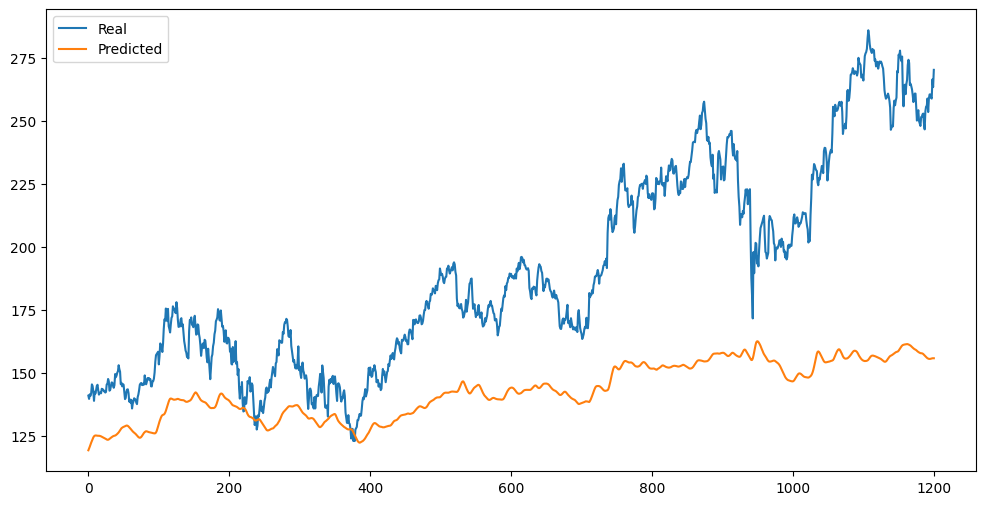

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_real, label="Real")
plt.plot(predictions_real, label="Predicted")
plt.legend()
plt.show()

# Teste de melhorias

In [102]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.tensorflow

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


In [103]:

# =========================
# 1. PREPARAÇÃO DOS DADOS
# =========================

df_aapl = df[df["Ticker"] == "AAPL"].copy()
df_aapl = df_aapl.sort_values("Date")

# 🔥 Feature Engineering
df_aapl["MA_10"] = df_aapl["Close"].rolling(10).mean()
df_aapl["MA_50"] = df_aapl["Close"].rolling(50).mean()
df_aapl["VOLATILITY"] = df_aapl["Close"].rolling(10).std()
df_aapl["RETURN"] = df_aapl["Close"].pct_change()
df_aapl["MOMENTUM"] = df_aapl["Close"] - df_aapl["Close"].shift(5)

df_aapl = df_aapl.dropna()

features = ["Open", "High", "Low", "Close", "Volume", "MA_10", "MA_50", "VOLATILITY", "RETURN", "MOMENTUM"]
data = df_aapl[features].values


In [104]:

# =========================
# 2. NORMALIZAÇÃO
# =========================

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


In [105]:

# =========================
# 3. CRIAR SEQUÊNCIAS (CLASSIFICAÇÃO)
# =========================

def create_sequences(data, window_size=60, horizon=5):
    X, y = [], []
    for i in range(window_size, len(data) - horizon):
        X.append(data[i-window_size:i])

        # 🔥 direção em 5 dias
        if data[i + horizon, 3] > data[i, 3]:
            y.append(1)
        else:
            y.append(0)

    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, window_size=60)


In [106]:

# =========================
# 4. SPLIT
# =========================

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train:", X_train.shape)


X_train: (4798, 60, 10)


In [107]:

# =========================
# 5. MODELO LSTM
# =========================

model = Sequential()

model.add(LSTM(
    32,
    return_sequences=True,
    input_shape=(X_train.shape[1], X_train.shape[2])
))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # classificação

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


/Users/viniciussouza/Codes/FIAP/FIAP_projeto_fase_4/venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [108]:

# =========================
# 6. EARLY STOPPING
# =========================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


In [109]:

# =========================
# 7. MLFLOW
# =========================

mlflow.set_experiment("LSTM_DIRECTION_PREDICTION")

with mlflow.start_run():

    mlflow.log_param("window_size", 60)
    mlflow.log_param("lstm_units", 32)
    mlflow.log_param("optimizer", "SGD")
    mlflow.log_param("learning_rate", 0.005)
    mlflow.log_param("features", features)

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test)

    mlflow.log_metric("loss", loss)
    mlflow.log_metric("accuracy", acc)

    mlflow.tensorflow.log_model(model, "model")


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5817 - loss: 0.6811 - val_accuracy: 0.5433 - val_loss: 0.6998
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5834 - loss: 0.6802 - val_accuracy: 0.5433 - val_loss: 0.6976
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5834 - loss: 0.6798 - val_accuracy: 0.5433 - val_loss: 0.6912
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5832 - loss: 0.6802 - val_accuracy: 0.5433 - val_loss: 0.6946
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5834 - loss: 0.6795 - val_accuracy: 0.5433 - val_loss: 0.7025
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5834 - loss: 0.6796 - val_accuracy: 0.5433 - val_loss: 0.6973
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5834 - loss: 0.6795 - val_accuracy: 0.5433 - val_loss: 0.6897
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5834 - loss: 0.6794 - val_accu

2026/04/21 17:53:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/21 17:53:41 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


In [113]:

# =========================
# 8. PREVISÃO
# =========================

pred_probs = model.predict(X_test)
threshold = 0.55

preds = []

for p in pred_probs:
    if p > threshold:
        preds.append(1)  # compra
    elif p < (1 - threshold):
        preds.append(0)  # vende
    else:
        preds.append(-1)  # NÃO FAZ NADA
        


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [115]:

# =========================
# 9. MÉTRICA PRINCIPAL
# =========================

accuracy = accuracy_score(y_test, preds)
print("Directional Accuracy:", accuracy)


Directional Accuracy: 0.32416666666666666


In [116]:

# =========================
# 10. SIMULAÇÃO DE LUCRO
# =========================

prices = df_aapl["Close"].values[-len(preds):]

profit = 0

for i in range(1, len(preds)):
    if preds[i] == 1:
        profit += (prices[i] - prices[i-1])
    elif preds[i] == 0:
        profit += (prices[i-1] - prices[i])  # venda (short)

print("Simulated Profit:", profit)

Simulated Profit: 122.5233154296875


# Teste Claude

Features: 13 | Amostras: 6091
X_train: (4842, 30, 13) | X_test: (1219, 30, 13)
Retorno médio treino : 0.1437% ± 2.1774%
Retorno médio teste  : 0.0789% ± 1.7390%


/Users/viniciussouza/Codes/FIAP/FIAP_projeto_fase_4/venv/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        39,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,977 (324.13 KB)

...

2026/04/26 22:39:33 INFO mlflow.tracking.fluent: Experiment with name 'LSTM_RETURN_V2' does not exist. Creating a new experiment.


Epoch 1/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.4595 - mae: 0.7896 - val_loss: 0.0598 - val_mae: 0.2102 - learning_rate: 5.0000e-04
Epoch 2/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.1997 - mae: 0.4552 - val_loss: 0.0538 - val_mae: 0.1864 - learning_rate: 5.0000e-04
Epoch 3/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.1213 - mae: 0.3236 - val_loss: 0.0450 - val_mae: 0.1407 - learning_rate: 5.0000e-04
Epoch 4/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0828 - mae: 0.2432 - val_loss: 0.0423 - val_mae: 0.1301 - learning_rate: 5.0000e-04
Epoch 5/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0650 - mae: 0.1933 - val_loss: 0.0385 - val_mae: 0.1078 - learning_rate: 5.0000e-04
Epoch 6/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0546 - mae: 0.1585 - val_loss: 0.0370 - val_mae: 0.1013 - learning_rate: 5.0000e-04
Epoch 7/150
152/152 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - loss: 0.0470 - mae: 0.1327 - val_loss: 0.0352 - val_mae:

2026/04/26 22:49:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



📊 MÉTRICAS DE AVALIAÇÃO
  MAE            : 1.2282%
  RMSE           : 1.7402%
  MAPE           : 103.01%
  DA             : 53.16%   ← acerto de direção geral
  DA Naive       : 51.56%  ← baseline
  DA Confiante   : 53.16%   ← só previsões no quartil top 25%
  Cobertura conf.: 100.0% das previsões
  ✅ Modelo supera baseline em +1.60pp


2026/04/26 22:49:35 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


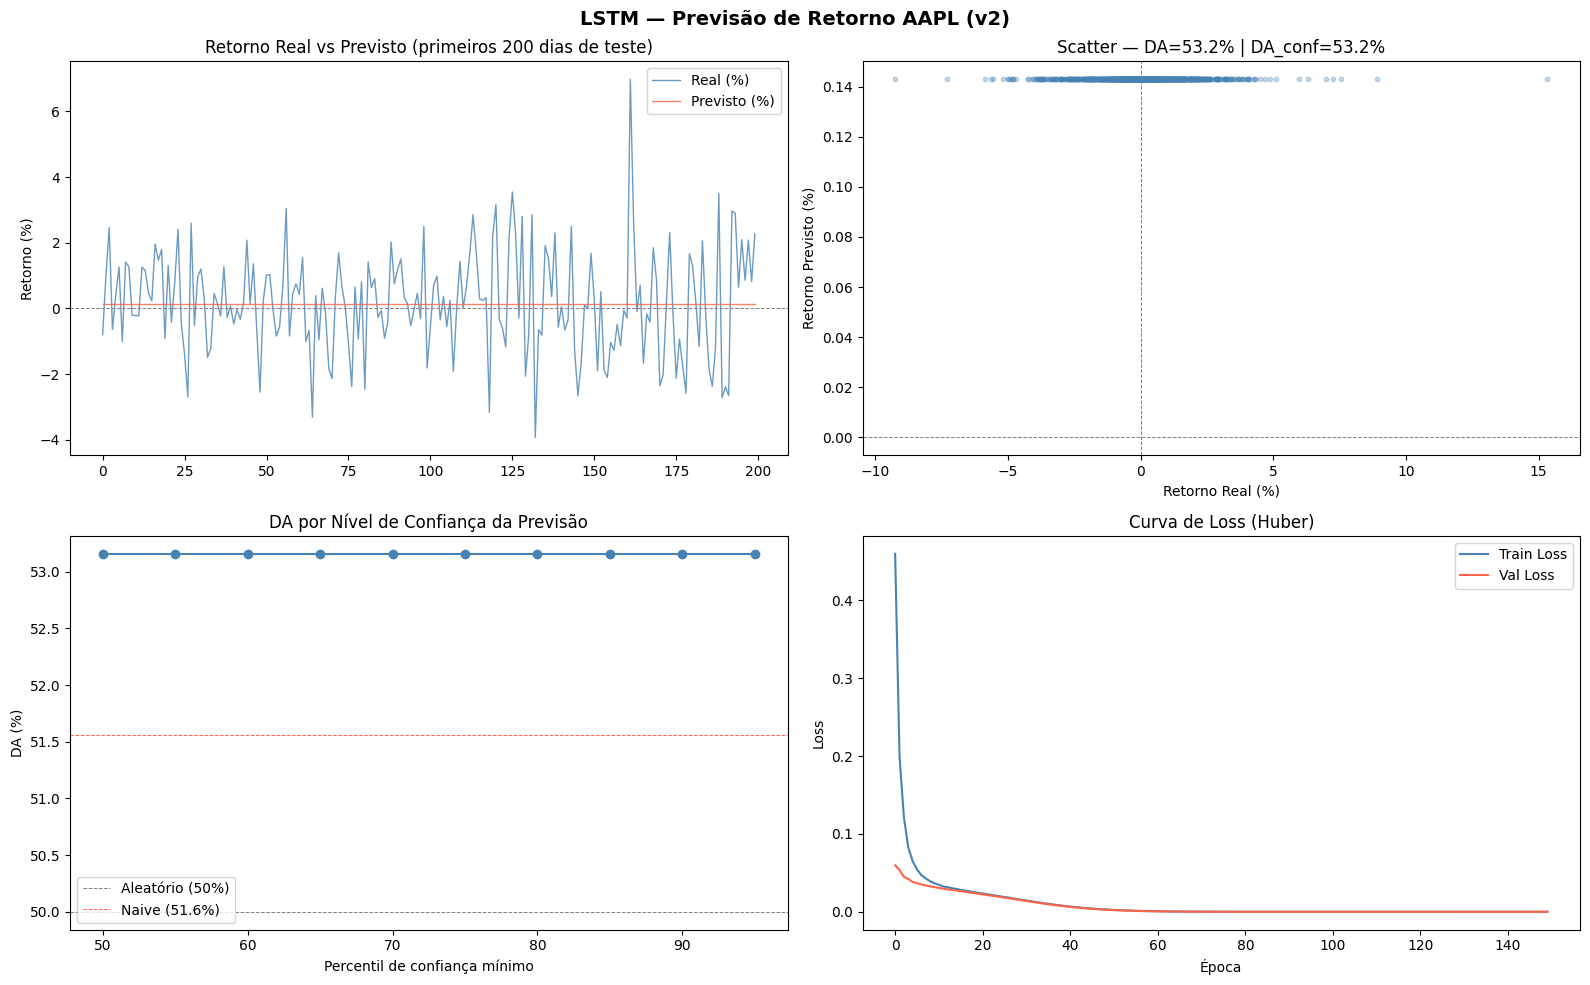

Gráfico salvo em lstm_v2_results.png


In [155]:
import numpy as np
import pandas as pd
import mlflow
import mlflow.tensorflow
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# =========================
# 1. PREPARAÇÃO DOS DADOS
# =========================

df_aapl = df[df["Ticker"] == "AAPL"].copy()
df_aapl = df_aapl.sort_values("Date").reset_index(drop=True)

# Features derivadas APENAS de dados passados (sem lookahead)
df_aapl["RETURN"]       = df_aapl["Close"].pct_change()
df_aapl["RETURN_2"]     = df_aapl["Close"].pct_change(2)
df_aapl["RETURN_5"]     = df_aapl["Close"].pct_change(5)
df_aapl["LOG_RETURN"]   = np.log(df_aapl["Close"] / df_aapl["Close"].shift(1))
df_aapl["HIGH_LOW_PCT"] = (df_aapl["High"] - df_aapl["Low"]) / df_aapl["Close"]
df_aapl["OPEN_CLOSE"]   = (df_aapl["Close"] - df_aapl["Open"]) / df_aapl["Open"]
df_aapl["VOLATILITY_5"] = df_aapl["RETURN"].rolling(5).std()
df_aapl["VOLATILITY_20"]= df_aapl["RETURN"].rolling(20).std()
df_aapl["VOL_CHANGE"]   = df_aapl["Volume"].pct_change()
df_aapl["MOMENTUM_5"]   = df_aapl["RETURN"].rolling(5).sum()
df_aapl["MOMENTUM_10"]  = df_aapl["RETURN"].rolling(10).sum()

# RSI corretamente calculado (usa só passado)
delta = df_aapl["Close"].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = -delta.clip(upper=0).rolling(14).mean()
df_aapl["RSI"] = 100 - (100 / (1 + gain / (loss + 1e-10)))

# MACD
df_aapl["MACD"] = (df_aapl["Close"].ewm(span=12).mean()
                 - df_aapl["Close"].ewm(span=26).mean())
df_aapl["MACD_SIGNAL"] = df_aapl["MACD"].ewm(span=9).mean()
df_aapl["MACD_HIST"]   = df_aapl["MACD"] - df_aapl["MACD_SIGNAL"]

df_aapl = df_aapl.dropna().reset_index(drop=True)

# TARGET: retorno do dia SEGUINTE (t+1)
df_aapl["TARGET"] = df_aapl["RETURN"].shift(-1)
df_aapl = df_aapl.dropna().reset_index(drop=True)

# Features — sem Close absoluto, sem MA longas (evita leak)
# Tudo em termos relativos/percentuais para ser estacionário
features = [
    "RETURN", "RETURN_2", "RETURN_5", "LOG_RETURN",
    "HIGH_LOW_PCT", "OPEN_CLOSE",
    "VOLATILITY_5", "VOLATILITY_20",
    "VOL_CHANGE", "MOMENTUM_5", "MOMENTUM_10",
    "RSI", "MACD_HIST",
]

print(f"Features: {len(features)} | Amostras: {len(df_aapl)}")

# =========================
# 2. SPLIT — sem normalização global (séries estacionárias não precisam)
# =========================

WINDOW_SIZE = 30   # reduzido: retornos têm memória curta
TARGET_COL  = "TARGET"

data   = df_aapl[features].values
target = df_aapl[TARGET_COL].values

split_idx = int(0.8 * len(data))

# =========================
# 3. NORMALIZAÇÃO POR JANELA (evita leak de escala)
# =========================

def create_sequences_window_norm(data, target, window_size=30):
    """
    Normaliza cada janela pelo seu próprio desvio padrão.
    Isso elimina o leak de escala e torna o modelo robusto
    a diferentes níveis de volatilidade.
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        window = data[i - window_size:i].copy()

        # Normaliza cada feature pela std da janela (z-score simplificado)
        std = window.std(axis=0)
        std[std < 1e-8] = 1.0   # evita divisão por zero
        window_norm = (window - window.mean(axis=0)) / std

        X.append(window_norm)
        y.append(target[i])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = create_sequences_window_norm(data, target, WINDOW_SIZE)

X_train, X_test = X_all[:split_idx - WINDOW_SIZE], X_all[split_idx - WINDOW_SIZE:]
y_train, y_test = y_all[:split_idx - WINDOW_SIZE], y_all[split_idx - WINDOW_SIZE:]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Retorno médio treino : {y_train.mean()*100:.4f}% ± {y_train.std()*100:.4f}%")
print(f"Retorno médio teste  : {y_test.mean()*100:.4f}% ± {y_test.std()*100:.4f}%")

# =========================
# 4. MODELO — Bidirectional LSTM + regularização
# =========================

def build_model(input_shape):
    model = Sequential([
        # Bidirecional captura padrões em ambas as direções temporais
        Bidirectional(
            LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
            input_shape=input_shape
        ),
        BatchNormalization(),
        Dropout(0.3),

        Bidirectional(LSTM(32, return_sequences=False, kernel_regularizer=l2(1e-4))),
        BatchNormalization(),
        Dropout(0.3),

        Dense(16, activation="relu", kernel_regularizer=l2(1e-4)),
        Dropout(0.2),
        Dense(1),  # regressão linear — retorno previsto
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),   # LR menor para convergência mais suave
        loss="huber",    # Huber é mais robusto a outliers que MSE para retornos financeiros
        metrics=["mae"]
    )
    return model

model = build_model((X_train.shape[1], X_train.shape[2]))
model.summary()

# =========================
# 5. CALLBACKS
# =========================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=7,
    min_lr=1e-6,
    verbose=1
)

# =========================
# 6. TREINAMENTO + MLFLOW
# =========================

mlflow.set_experiment("LSTM_RETURN_V2")

with mlflow.start_run():

    mlflow.log_params({
        "window_size":    WINDOW_SIZE,
        "target":         "return_t+1",
        "architecture":   "BiLSTM 64->32",
        "optimizer":      "Adam",
        "learning_rate":  0.0005,
        "loss":           "huber",
        "dropout":        0.3,
        "l2_reg":         1e-4,
        "batch_size":     32,
        "normalization":  "per_window_zscore",
        "features":       features,
    })

    history = model.fit(
        X_train, y_train,
        epochs=150,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    # =========================
    # 7. AVALIAÇÃO
    # =========================

    y_pred = model.predict(X_test, verbose=0).flatten()
    y_real = y_test

    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    mask_mape = np.abs(y_real) > 0.0005
    mape = np.mean(np.abs((y_real[mask_mape] - y_pred[mask_mape])
                           / y_real[mask_mape])) * 100

    # Directional Accuracy
    da       = np.mean(np.sign(y_real) == np.sign(y_pred)) * 100
    da_naive = np.mean(np.sign(y_real[1:]) == np.sign(y_real[:-1])) * 100

    # DA por quartil de confiança (quanto mais extrema a previsão, mais confiável?)
    conf = np.abs(y_pred)
    q75  = np.percentile(conf, 75)
    mask_conf = conf >= q75
    da_conf = np.mean(np.sign(y_real[mask_conf]) == np.sign(y_pred[mask_conf])) * 100

    print("\n" + "="*50)
    print("📊 MÉTRICAS DE AVALIAÇÃO")
    print("="*50)
    print(f"  MAE            : {mae*100:.4f}%")
    print(f"  RMSE           : {rmse*100:.4f}%")
    print(f"  MAPE           : {mape:.2f}%")
    print(f"  DA             : {da:.2f}%   ← acerto de direção geral")
    print(f"  DA Naive       : {da_naive:.2f}%  ← baseline")
    print(f"  DA Confiante   : {da_conf:.2f}%   ← só previsões no quartil top 25%")
    print(f"  Cobertura conf.: {mask_conf.mean()*100:.1f}% das previsões")
    print("="*50)

    delta_da = da - da_naive
    if delta_da > 0:
        print(f"  ✅ Modelo supera baseline em +{delta_da:.2f}pp")
    else:
        print(f"  ⚠️  Modelo abaixo do baseline em {delta_da:.2f}pp")

    mlflow.log_metrics({
        "MAE_pct":    mae * 100,
        "RMSE_pct":   rmse * 100,
        "MAPE":       mape,
        "DA":         da,
        "DA_naive":   da_naive,
        "DA_conf":    da_conf,
        "delta_DA":   delta_da,
    })

    mlflow.tensorflow.log_model(model, "model")

# =========================
# 8. VISUALIZAÇÕES
# =========================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Retorno real vs previsto
ax = axes[0, 0]
ax.plot(y_real[:200] * 100,  label="Real (%)",    color="steelblue", alpha=0.8, linewidth=1)
ax.plot(y_pred[:200] * 100,  label="Previsto (%)", color="tomato",   alpha=0.8, linewidth=1)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.7)
ax.set_title("Retorno Real vs Previsto (primeiros 200 dias de teste)")
ax.set_ylabel("Retorno (%)")
ax.legend()

# Plot 2: Scatter real vs previsto
ax = axes[0, 1]
ax.scatter(y_real * 100, y_pred * 100, alpha=0.3, s=10, color="steelblue")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.7)
ax.axvline(0, color="gray", linestyle="--", linewidth=0.7)
ax.set_xlabel("Retorno Real (%)")
ax.set_ylabel("Retorno Previsto (%)")
ax.set_title(f"Scatter — DA={da:.1f}% | DA_conf={da_conf:.1f}%")

# Plot 3: DA por nível de confiança
ax = axes[1, 0]
percentiles = range(50, 96, 5)
da_by_conf  = []
for p in percentiles:
    threshold = np.percentile(conf, p)
    m = conf >= threshold
    if m.sum() > 10:
        da_by_conf.append(np.mean(np.sign(y_real[m]) == np.sign(y_pred[m])) * 100)
    else:
        da_by_conf.append(np.nan)
ax.plot(list(percentiles), da_by_conf, marker="o", color="steelblue")
ax.axhline(50, color="gray", linestyle="--", linewidth=0.7, label="Aleatório (50%)")
ax.axhline(da_naive, color="tomato", linestyle="--", linewidth=0.7, label=f"Naive ({da_naive:.1f}%)")
ax.set_xlabel("Percentil de confiança mínimo")
ax.set_ylabel("DA (%)")
ax.set_title("DA por Nível de Confiança da Previsão")
ax.legend()

# Plot 4: Loss curves
ax = axes[1, 1]
ax.plot(history.history["loss"],     label="Train Loss", color="steelblue")
ax.plot(history.history["val_loss"], label="Val Loss",   color="tomato")
ax.set_title("Curva de Loss (Huber)")
ax.set_ylabel("Loss")
ax.set_xlabel("Época")
ax.legend()

plt.suptitle("LSTM — Previsão de Retorno AAPL (v2)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("lstm_v2_results.png", dpi=150)
plt.show()
print("Gráfico salvo em lstm_v2_results.png")